# Canlı Modele BOTAŞ Gaz Tarifesi Feature'ı — Walk-Forward Backtest

**Konum:** `experiments/notebooks/03_ptf_model_comparison/05_gas_tariff_feature_backtest.ipynb`
**Tarih:** 18 Ağustos 2026
**İlgili:** `05_crisis_analysis/03_gas_tariff_discovery.ipynb` · `METRICS.md` · `EXPERIMENT_WORKFLOW.md`

## Soru

Canlı model (`lgb_lag0_v2`) gaz maliyetini `natural_gas_grf_lag_48` üzerinden görüyor:
EPİAŞ'ın gaz piyasası **referans** fiyatı, 48 saat gecikmeli. Santrallerin fiilen ödediği
ise **BOTAŞ elektrik üretim tarifesi** (`silver.gas_tariff_electricity`).

Kriz analiz modelinde bu değişiklik ölçülebilir kazanç sağladı (MAE 10,29 → 9,54).
**Canlı modelde de sağlar mı?**

## Neden sağlayabilir — ve neden sızıntı değil

| | GRF | BOTAŞ tarifesi |
|---|---|---|
| Ne | piyasada oluşan referans fiyat | idari olarak belirlenen satış fiyatı |
| Ne zaman belli olur | gün içinde | **ayın başında, ay boyunca sabit** |
| Modelde kullanımı | 48h gecikmeli olmak zorunda | **gecikmesiz kullanılabilir** |

Tahmin anı D günü 04:00, hedef D+1. O saatte D+1'in GRF'si yok — o yüzden 48 saat
gecikme koyuyoruz. Tarife ise zaten duyurulmuş durumda. **Bu, sızıntı değil; gerçekten
önceden bilinen bir bilgi.**

Tek dikkat: TL→USD çevrimi. Tarifenin kendisi biliniyor ama hedef günün kuru
bilinmiyor. Bu yüzden çevrimde `usd_try.shift(24)` kullanılır — canlı pipeline'ın
04:00'te bilebileceği son kur. Hedef saatin kendi kuru kullanılsaydı backtest
kendini kayırırdı (aynı tuzak `backfill_gold_predictions.py`'de de not düşülmüş).

## Üç kol

| Kol | Feature seti |
|---|---|
| `baseline` | canlı robust set (71 feature, `natural_gas_grf_lag_48` dahil) |
| `tarife_ek` | baseline **+** `gas_tariff_usd_lag0` |
| `tarife_yerine` | baseline **−** `natural_gas_grf_lag_48` **+** `gas_tariff_usd_lag0` |

## Seri bütünlüğü

`silver.gas_tariff_electricity` 2021-01 → 2026-04 arasını **boşluksuz** kapsıyor.

İlk derlemede 5 Nisan – 2 Temmuz 2025 aralığı boş kalmıştı (2.112 saat). Sebep veri
yokluğu değil, **çıkarma hatasıydı**: duyuru arşivde vardı ama haberin başlığı
elektrik perakende zammıyla ilgiliydi (`62869`, "Elektrik tarifelerine gecikmeli zam")
ve gaz tarifesi gövdenin sonunda geçiyordu — başlık/bölüm filtresi yakalamadı.
Değer: 12.000 × 1,242 = **14.904 TL/1000m³**. Temmuz'un resmî çıpası 15.000 olduğu
için kalan belirsizlik %0,6.

**Ders:** tarife duyuruları her zaman "gaz" başlıklı haberde olmuyor. Seri
güncellenirken başlığa değil gövdeye bakılmalı. Aşağıdaki hücre boşluk kalmadığını
doğruluyor.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(project_root / 'scripts') not in sys.path:
    sys.path.insert(0, str(project_root / 'scripts'))

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from db.connection import get_db_engine
from scripts.predict_daily_pipeline import load_all_historical_data
from src.features.feature_engineering import build_robust_features, get_feature_columns
from src.models.lightgbm_model import LightGBMForecaster

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

engine = get_db_engine()

# ── Ayarlar ────────────────────────────────────────────────────────────────
N_GUN = 180            # test penceresi (gün). Maliyet: ~3,7 sn/fit
QUANTILE_BASLARI = [0.50]   # [0.10, 0.50, 0.90] yaparsan kapsama da ölçülür (3 kat süre)
SONUC_CSV = project_root / 'experiments' / 'gas_tariff_backtest_results.csv'
YENIDEN_KOS = False    # True yaparsan önbelleği yok sayar

n_fit = N_GUN * len(QUANTILE_BASLARI) * 3
print(f'{N_GUN} gün x {len(QUANTILE_BASLARI)} baş x 3 kol = {n_fit} fit  ->  ~{n_fit*3.7/60:.0f} dk')
print('önbellek:', 'VAR' if SONUC_CSV.exists() else 'yok', f'({SONUC_CSV.name})')

180 gün x 1 baş x 3 kol = 540 fit  ->  ~33 dk
önbellek: yok (gas_tariff_backtest_results.csv)


## 1. Tarife serisi canlı eğitim penceresini kapsıyor mu

Canlı model `TRAINING_DATA_START = 2023-01-01`'den eğitiliyor. Tarife serisi
2021'den başlıyor, yani kapsam sorunu yok — ama boşluğun nereye düştüğü önemli.

In [2]:
kapsam = pd.read_sql(text("""
    SELECT to_char(ts AT TIME ZONE 'Europe/Istanbul','YYYY') yil,
           count(*) saat,
           count(price_try_1000m3) tarifeli,
           sum(tariff_is_gap::int) bosluk_saat
    FROM silver.gas_cost_hourly
    WHERE ts >= '2023-01-01'
    GROUP BY 1 ORDER BY 1
"""), engine)
display(kapsam)

bosluk = pd.read_sql(text("""
    SELECT min(ts AT TIME ZONE 'Europe/Istanbul') bas,
           max(ts AT TIME ZONE 'Europe/Istanbul') bit, count(*) saat
    FROM silver.gas_cost_hourly WHERE tariff_is_gap
"""), engine)
display(bosluk)

,yil,saat,tarifeli,bosluk_saat
0,2023,8760,8760,0
1,2024,8784,8784,0
2,2025,8760,8760,0
3,2026,5520,5520,0


,bas,bit,saat
0,None,None,0


## 2. Feature kurulumu

Canlı `build_robust_features()` aynen kullanılır — üretim kodu değiştirilmez.
Tarife sütunu ayrı çekilip birleştirilir.

In [3]:
def tarife_ekle(df_feat):
    """Canlı feature çerçevesine gas_tariff_usd_lag0 ekler.

    TL tarifesi tahmin anında bilinir (ayın başında duyurulur, ay boyunca sabit).
    Kur bilinmez -> usd_try.shift(24): canlı pipeline'ın 04:00'te bilebileceği son kur.
    1000 Sm3 = 10,646 MWh (9155 Kcal/Sm3 üst ısıl değer, BOTAŞ tarife dipnotu).
    """
    t = pd.read_sql(text("""
        SELECT ts, price_try_1000m3, tariff_is_gap FROM silver.gas_cost_hourly
        WHERE ts >= '2022-12-01' ORDER BY ts
    """), engine)
    t['ts'] = pd.to_datetime(t.ts, utc=True).dt.tz_convert('Europe/Istanbul')
    t = t.set_index('ts')

    out = df_feat.copy()
    out['gas_tariff_try_1000m3'] = t.price_try_1000m3.astype(float).reindex(out.index).ffill()
    out['gas_tariff_is_gap'] = t.tariff_is_gap.reindex(out.index).ffill().fillna(False).astype(bool)

    fx_bilinen = out['usd_try'].shift(24).replace(0, np.nan)
    out['gas_tariff_usd_lag0'] = ((out.gas_tariff_try_1000m3 / 10.646) / fx_bilinen).astype(float)
    return out


raw = load_all_historical_data()
feat = tarife_ekle(build_robust_features(raw))

BASE_COLS = get_feature_columns('robust', feat)
KOLLAR = {
    'baseline':      BASE_COLS,
    'tarife_ek':     BASE_COLS + ['gas_tariff_usd_lag0'],
    'tarife_yerine': [c for c in BASE_COLS if c != 'natural_gas_grf_lag_48'] + ['gas_tariff_usd_lag0'],
}
for ad, cols in KOLLAR.items():
    print(f'{ad:16s} {len(cols)} feature')

print()
print(feat[['natural_gas_grf_lag_48', 'gas_tariff_usd_lag0']].describe().round(1).loc[['min','mean','max']])

baseline         71 feature
tarife_ek        72 feature
tarife_yerine    71 feature

      natural_gas_grf_lag_48  gas_tariff_usd_lag0
min                     34.4                 29.7
mean                   378.9                 38.1
max                   1047.1                 90.3


### 📌 Bölüm 2 Analiz Notları

- **DÜZELTME:** ilk yazdığımda "iki seri aynı büyüklük mertebesinde" demiştim, değil.
  Çıktıya göre `natural_gas_grf_lag_48` ortalaması **378,9**, `gas_tariff_usd_lag0`
  ortalaması **38,1** — on kat fark. GRF'yi USD/1000 Sm³ olarak bırakıyorum, tarifeyi
  ise USD/MWh'ye çeviriyorum (÷10,646). Ağaç modeli ölçek bağımsız olduğu için sonucu
  etkilemiyor, ama karşılaştırmalı okurken karıştırılmamalı.
- `tarife_ek` ikisini birlikte verir: model hangisini kullanacağına kendisi karar
  verir. `tarife_yerine` ise iddiayı sertleştirir — GRF tamamen çıkar.
- Fark anlamlıysa `tarife_yerine`'de görünmeli; `tarife_ek` daha güvenli ama
  ikisi arasında ayrım yapamayabilir (LightGBM korele iki sütunu bölüşür).

## 3. Backtest — canlı protokolün aynısı

`scripts/backfill_gold_predictions.py` ile birebir aynı şema:

- **Günlük walk-forward, genişleyen pencere.** Her hedef gün için model o güne kadarki
  tüm veriyle sıfırdan eğitilir (canlı model de her gün sıfırdan eğitiliyor).
- **Eşleştirilmiş.** Üç kol aynı günleri, aynı eğitim penceresini, aynı `random_state`'i
  kullanır. Tek fark feature seti — böylece fark başka bir şeye atfedilemez.
- **Kur ileriye bakmaz:** eğitim penceresinin son bilinen kuru (`iloc[-1]`).

Sonuçlar CSV'ye önbelleklenir; notebook'u yeniden açtığında beklemezsin.

In [4]:
TARGET = 'mcp_price_usd'

def kos_backtest(feat, kollar, n_gun, quantiller):
    """Eşleştirilmiş walk-forward. Saatlik tahmin döndürür (uzun format)."""
    # Tüm kolların ihtiyaç duyduğu sütunlarda dropna -> üç kol AYNI satır kümesinde
    gerekli = sorted({c for cols in kollar.values() for c in cols} | {TARGET})
    m = feat.dropna(subset=gerekli).copy()
    max_ts = m.index.max()
    kayit = []

    t0 = time.time()
    for i, gun_idx in enumerate(range(n_gun - 1, -1, -1)):
        test_bit = max_ts - pd.Timedelta(days=gun_idx)
        test_bas = test_bit - pd.Timedelta(hours=23)
        egitim_bit = test_bas - pd.Timedelta(hours=1)

        tr = m.loc[:egitim_bit]
        te = m.loc[test_bas:test_bit]
        if len(tr) < 1000 or len(te) < 12:
            continue

        for ad, cols in kollar.items():
            tahmin = {}
            for q in quantiller:
                fc = LightGBMForecaster(params={
                    'objective': 'quantile', 'alpha': q,
                    'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 8,
                    'num_leaves': 63, 'min_child_samples': 10,
                    'verbose': -1, 'random_state': 42,
                })
                fc.fit(tr[cols], tr[TARGET].values, feature_columns=cols)
                tahmin[q] = fc.predict(te[cols])

            p50 = tahmin.get(0.50)
            satir = pd.DataFrame({'ts': te.index, 'kol': ad,
                                  'gercek': te[TARGET].values, 'p50': p50})
            if 0.10 in tahmin and 0.90 in tahmin:
                satir['p10'] = np.minimum(tahmin[0.10], p50)
                satir['p90'] = np.maximum(tahmin[0.90], p50)
            kayit.append(satir)

        if i % 20 == 0:
            gecen = time.time() - t0
            kalan = gecen / (i + 1) * (n_gun - i - 1)
            print(f'  {i+1:3d}/{n_gun}  {test_bit.date()}  geçen {gecen/60:.1f}dk  kalan ~{kalan/60:.0f}dk')

    return pd.concat(kayit, ignore_index=True)


if SONUC_CSV.exists() and not YENIDEN_KOS:
    bt = pd.read_csv(SONUC_CSV, parse_dates=['ts'])
    bt['ts'] = pd.to_datetime(bt.ts, utc=True).dt.tz_convert('Europe/Istanbul')
    print(f'önbellekten okundu: {len(bt)} satır, {bt.kol.nunique()} kol, '
          f'{bt.ts.min().date()} → {bt.ts.max().date()}')
else:
    bt = kos_backtest(feat, KOLLAR, N_GUN, QUANTILE_BASLARI)
    bt.to_csv(SONUC_CSV, index=False)
    print(f'yazıldı: {SONUC_CSV}')

# Boşluk test penceresine düşüyor mu?
gap = feat.loc[bt.ts.min():bt.ts.max(), 'gas_tariff_is_gap'].sum()
print(f'test penceresinde tarife boşluğu: {int(gap)} saat', '(TEMİZ)' if gap == 0 else '(DİKKAT)')

    1/180  2026-02-20  geçen 0.2dk  kalan ~33dk


   21/180  2026-03-12  geçen 4.0dk  kalan ~30dk


   41/180  2026-04-01  geçen 7.7dk  kalan ~26dk


   61/180  2026-04-21  geçen 11.5dk  kalan ~22dk


   81/180  2026-05-11  geçen 15.3dk  kalan ~19dk


  101/180  2026-05-31  geçen 18.4dk  kalan ~14dk


  121/180  2026-06-20  geçen 22.1dk  kalan ~11dk


  141/180  2026-07-10  geçen 26.0dk  kalan ~7dk


  161/180  2026-07-30  geçen 29.7dk  kalan ~4dk


yazıldı: /Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini/experiments/gas_tariff_backtest_results.csv
test penceresinde tarife boşluğu: 0 saat (TEMİZ)


## 4. Çekirdek metrik seti

`METRICS.md`'nin şart koştuğu set. **Tek metriğe bakılmaz** — özellikle WAPE'e:
düşük fiyat rejiminde payda çöktüğü için model iyileşse bile WAPE kötüleşebilir.

Naive tanımı (Lago et al.): Pzt/Cmt/Paz → geçen hafta aynı saat; Sal–Cum → dün aynı saat.

In [5]:
def naive_seri(gercek_ser):
    """Lago naive: hafta sonu+Pzt -> 168h önce, diğer günler -> 24h önce."""
    dow = gercek_ser.index.dayofweek
    nv1 = gercek_ser.shift(24)
    nv7 = gercek_ser.shift(168)
    return pd.Series(np.where(np.isin(dow, [0, 5, 6]), nv7, nv1), index=gercek_ser.index)


gercek_tam = feat[TARGET].dropna()
naive_tam = naive_seri(gercek_tam)

def metrikler(g):
    g = g.set_index('ts').sort_index()
    nv = naive_tam.reindex(g.index)
    ok = nv.notna()
    hata = g.p50 - g.gercek
    d = {
        'n': len(g),
        'MAE': hata.abs().mean(),
        'BIAS': hata.mean(),
        'rMAE': hata[ok].abs().mean() / np.abs(nv[ok] - g.gercek[ok]).mean(),
        'sMAPE%': 100 * (2 * hata.abs() / (g.p50.abs() + g.gercek.abs()).replace(0, np.nan)).mean(),
        'WAPE%': 100 * hata.abs().sum() / g.gercek.sum(),
    }
    if 'p10' in g.columns:
        d['kapsama%'] = 100 * ((g.gercek >= g.p10) & (g.gercek <= g.p90)).mean()
    return pd.Series(d)


ozet = bt.groupby('kol').apply(metrikler, include_groups=False)
ozet = ozet.reindex(['baseline', 'tarife_ek', 'tarife_yerine'])
display(ozet.round(3))

base = ozet.loc['baseline']
fark = (ozet - base).drop(index='baseline')
print('\nbaseline\'a göre fark (negatif = iyileşme):')
display(fark[['MAE', 'BIAS', 'rMAE', 'sMAPE%', 'WAPE%']].round(3))

,n,MAE,BIAS,rMAE,sMAPE%,WAPE%
kol,,,,,,
baseline,4248.0,9.769,2.436,0.817,52.723,28.078
tarife_ek,4248.0,9.765,2.518,0.817,52.265,28.069
tarife_yerine,4248.0,9.860,2.521,0.825,52.168,28.341



baseline'a göre fark (negatif = iyileşme):


,MAE,BIAS,rMAE,sMAPE%,WAPE%
kol,,,,,
tarife_ek,-0.003,0.082,-0.000,-0.458,-0.010
tarife_yerine,0.092,0.085,0.008,-0.555,0.263


## 5. Eşleştirilmiş günlük fark — kazanç tutarlı mı, birkaç günden mi geliyor

Toplam MAE farkı tek başına yeterli değil: iki-üç günün büyük hatası ortalamayı
taşıyabilir. Günlük eşleştirilmiş farka bakılır — kolların **kaç günde** daha iyi
olduğu ve farkın dağılımı.

tarife_ek        baseline'dan iyi olduğu gün: 91/177 (%51)  ort fark $-0.003  medyan $-0.027
tarife_yerine    baseline'dan iyi olduğu gün: 86/177 (%49)  ort fark $+0.092  medyan $+0.034


/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_72759/758917261.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax[1].boxplot([d2[c].dropna() for c in d2.columns], vert=True)


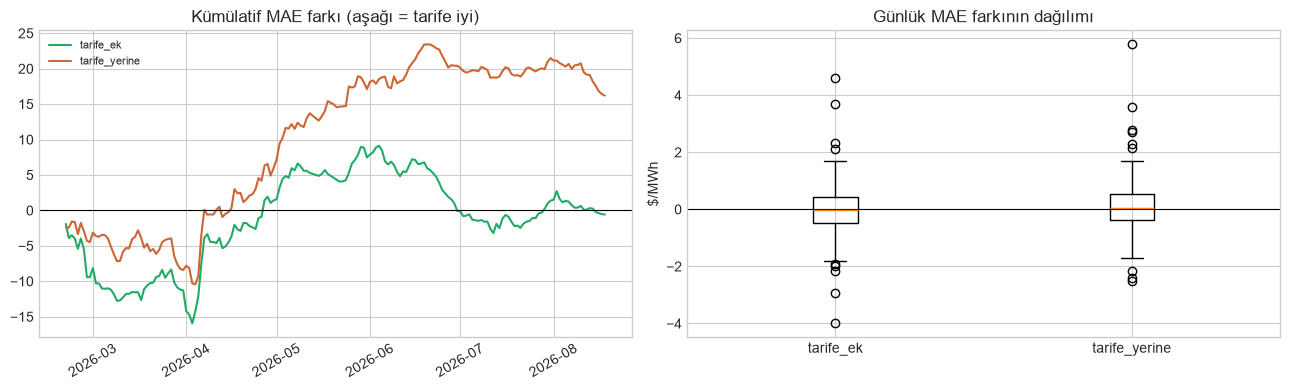

In [6]:
g = bt.copy()
g['gun'] = g.ts.dt.date
g['ae'] = (g.p50 - g.gercek).abs()
gunluk = g.groupby(['gun', 'kol']).ae.mean().unstack('kol')

for kol in ['tarife_ek', 'tarife_yerine']:
    d = gunluk[kol] - gunluk['baseline']
    kazanan = (d < 0).sum()
    print(f'{kol:16s} baseline\'dan iyi olduğu gün: {kazanan}/{len(d)} (%{100*kazanan/len(d):.0f})  '
          f'ort fark ${d.mean():+.3f}  medyan ${d.median():+.3f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for kol, c in [('tarife_ek', '#2a6'), ('tarife_yerine', '#c63')]:
    ax[0].plot(gunluk.index, (gunluk[kol] - gunluk['baseline']).cumsum(), label=kol, color=c)
ax[0].axhline(0, color='k', lw=.8)
ax[0].set_title('Kümülatif MAE farkı (aşağı = tarife iyi)'); ax[0].legend(fontsize=8)
ax[0].tick_params(axis='x', rotation=30)

d2 = pd.DataFrame({k: gunluk[k] - gunluk['baseline'] for k in ['tarife_ek', 'tarife_yerine']})
bp = ax[1].boxplot([d2[c].dropna() for c in d2.columns], vert=True)
ax[1].set_xticklabels(d2.columns)
ax[1].axhline(0, color='k', lw=.8)
ax[1].set_title('Günlük MAE farkının dağılımı'); ax[1].set_ylabel('$/MWh')
plt.tight_layout(); plt.show()

## 6. Fiyat dilimine göre

`METRICS.md` ve `LOW_PRICE_REGIME_ANALYSIS.md`: modelin bilinen zayıflığı ucuz
dilimde yukarı sapması (BIAS +$8,56, $0-10 aralığında). Yakıt maliyeti feature'ının
oraya dokunup dokunmadığı ayrıca bakılır — genel MAE'de görünmeyebilir.

In [7]:
bins = [-1, 0, 10, 20, 40, 60, 90, 1e9]
etiket = ['= $0', '$0-10', '$10-20', '$20-40', '$40-60', '$60-90', '> $90']
g['dilim'] = pd.cut(g.gercek, bins=bins, labels=etiket)

dilim = g.groupby(['dilim', 'kol'], observed=True).apply(
    lambda x: pd.Series({'n': len(x), 'MAE': (x.p50 - x.gercek).abs().mean(),
                         'BIAS': (x.p50 - x.gercek).mean()}), include_groups=False)
display(dilim.unstack('kol').round(2))

n                              MAE                             BIAS                        
kol    baseline tarife_ek tarife_yerine baseline tarife_ek tarife_yerine baseline tarife_ek tarife_yerine
dilim                                                                                                    
= $0      358.0     358.0         358.0     3.04      3.39          3.21     3.04      3.39          3.21
$0-10    1074.0    1074.0        1074.0     7.98      8.14          8.11     6.87      7.13          7.06
$10-20    315.0     315.0         315.0    11.78     11.89         12.19     8.15      8.26          8.46
$20-40    840.0     840.0         840.0    12.57     12.16         12.50     5.57      5.43          5.44
$40-60    537.0     537.0         537.0    12.59     12.78         12.83     3.20      2.98          3.18
$60-90    966.0     966.0         966.0     8.97      8.94          9.01    -5.14     -5.08         -5.10
> $90     158.0     158.0         158.0    13.61     13.07         13.19   -13.38    -12.87        -12.91

## 7. Karar

Aşağıdaki hücre `gold.experiment_results`'a yazar (`EXPERIMENT_WORKFLOW.md` §1).

**Kabul ölçütü tek metrik değil.** Bir kolun canlıya aday olması için:

1. **rMAE düşmeli** — literatürle kıyaslanabilir tek metrik, rejimden bağımsız
2. **Günlerin belirgin çoğunluğunda kazanmalı** — birkaç günün taşıdığı ortalama sayılmaz
3. **BIAS kötüleşmemeli** — özellikle ucuz dilimde
4. Kazanç, tarife serisinin bakım maliyetini (yılda 2-3 kez elle güncelleme,
   5 Nis 2025 boşluğunun kapatılması) haklı çıkarmalı

Ölçütler sağlanmazsa sonuç **negatif olarak kaydedilir ve kapatılır** — kriz
analizinde işe yaraması canlıda da yarayacağı anlamına gelmez. Kriz modeli 2021'den
eğitiliyor ve tarife/GRF ayrışması asıl orada (2021-2023); canlı model 2023'ten
eğitiliyor ve 2024 sonrası iki seri neredeyse örtüşüyor (ort |oran−1| = %6).
**Bu yüzden canlıda kazanç beklentisi baştan mütevazı.**

In [8]:
kayit_sql = text("""
    INSERT INTO gold.experiment_results
        (experiment_name, model_type, feature_set, hyperparameters, backtest_type,
         backtest_days, train_start, test_start, test_end, mae_usd, wape_pct,
         rmse_usd, low_price_mae_usd, notes)
    VALUES (:ad, 'lightgbm_quantile_p50', :fs, :hp, 'daily_walkforward_expanding',
            :gun, :tr_bas, :te_bas, :te_bit, :mae, :wape, :rmse, :dusuk_mae, :not)
""")

hp = '{"objective":"quantile","alpha":0.5,"n_estimators":300,"learning_rate":0.03,' \
     '"max_depth":8,"num_leaves":63,"min_child_samples":10,"random_state":42}'

with engine.connect() as conn:
    for kol in ozet.index:
        s = bt[bt.kol == kol]
        hata = s.p50 - s.gercek
        ucuz = s[s.gercek <= 10]
        conn.execute(kayit_sql, {
            'ad': f'gas_tariff_{kol}', 'fs': f'robust+{kol}', 'hp': hp,
            'gun': int(N_GUN),
            'tr_bas': pd.Timestamp('2023-01-01').date(),
            'te_bas': s.ts.min().date(), 'te_bit': s.ts.max().date(),
            'mae': float(hata.abs().mean()),
            'wape': float(100 * hata.abs().sum() / s.gercek.sum()),
            'rmse': float(np.sqrt((hata ** 2).mean())),
            'dusuk_mae': float((ucuz.p50 - ucuz.gercek).abs().mean()) if len(ucuz) else None,
            'not': f'rMAE={ozet.loc[kol,"rMAE"]:.3f}; BIAS={ozet.loc[kol,"BIAS"]:+.2f}; '
                   f'BOTAS tarifesi denemesi; tarife bosluk 5Nis-2Tem2025 egitimde',
        })
    conn.commit()
print('gold.experiment_results\'a yazıldı')

gold.experiment_results'a yazıldı
